texto diapos + códigos con healpy




$Q_{DM}$:

$$T = \frac{|H_{0, \text{Planck}} - H_{0, \text{Pantheon}}|}{\sqrt{\sigma_{\text{Planck}}^2 + \sigma_{\text{Pantheon}}^2}}$$

$Q_{DMAP} = 2 \left( \ln \mathcal{P}_{max}^A + \ln \mathcal{P}_{max}^B - \ln \mathcal{P}_{max}^{A+B} \right)$

### Resumen de las métricas de tensión cosmológica (Planck vs Pantheon)

| Datasets | Método / Herramienta | $Q_{DM}$ | Tensión ($\sigma$) |
| :---:     | :---:               | :---:  |:---:|
| Planck / PPS | Multimeter      | 32.012  | 5.31 |
| Planck / DES Dovekie (BAO) | Multimeter      | 0.56  | 0.31 |
| Planck / DES 5YR | Multimeter      | 0.63  | 0.34 |

<br>
<small><i><b>Nota:</b> Para la tensión 1D (Regla del Dedo) se utilizaron los valores marginados de la constante de Hubble: $H_0^{\rm Planck} = 67.36 \pm 0.54$ y $H_0^{\rm Pantheon} = 73.48 \pm 1.03$. Los grados de libertad (G.L.) corresponden a la dimensionalidad del espacio de parámetros evaluado.</i></small>

$H_0^{\rm Planck} = 67.36 \pm 0.54 \, \text{km s}^{-1} \text{Mpc}^{-1}$

$H_0^{\rm PPS} = 73.48 \pm 1.03 \, \text{km s}^{-1} \text{Mpc}^{-1}$

$\Omega_m^{\rm Planck} = 0.32 \pm 0.01 $

$\Omega_m^{\rm PPS} = 0.30 \pm 0.05 $

Tensión 1D: 0.23 $\sigma$

$$
H^2(z) = H_0^2 \left[ \Omega_m (1+z)^3 + \Omega_\Lambda \right]
$$

$$
S_8 = \sigma_8 \sqrt{\frac{\Omega_m}{0.3}}
$$

<Figure size 1200x700 with 0 Axes>

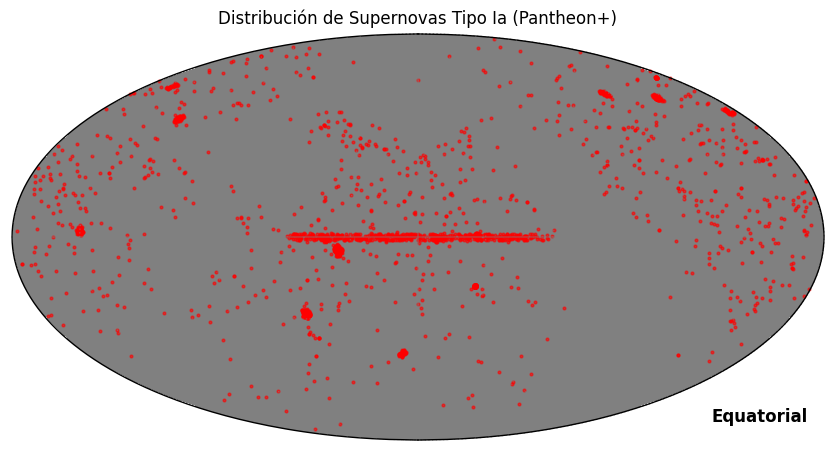

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install healpy
import healpy as hp

# ==============================================================================
# 1. CARGAR LOS DATOS
# ==============================================================================
# Por cómo se ve tu texto pegado, es probable que el archivo esté separado
# por espacios o comas. Usamos pandas para leerlo.
# (Ajusta el nombre del archivo y el separador 'sep' si es necesario)
df = pd.read_csv('all_redshifts_PVs.csv', sep=',')
# Si arroja un error porque está separado por espacios, cambia a: sep='\s+'

# Extraemos las columnas que nos interesan (asegúrate de que los nombres
# coincidan con el encabezado real de tu CSV)
ra = df['RA'].values
dec = df['Dec'].values

# ==============================================================================
# 2. CONVERSIÓN DE COORDENADAS PARA HEALPY
# ==============================================================================
# - RA va de 0 a 360 grados. En healpy esto es la longitud phi (en radianes).
# - Dec va de -90 a +90 grados. En healpy el Polo Norte es theta=0, por lo que
#   la colatitud theta es (90 - Dec) convertida a radianes.

phi = np.radians(ra)
theta = np.radians(90.0 - dec)

# ==============================================================================
# 3. CREAR EL MAPA
# ==============================================================================
plt.figure(figsize=(12, 7))

# 3.1 Creamos un "mapa de fondo" vacío.
# NSIDE=32 es suficiente para un fondo liso. npix es el número total de píxeles.
nside = 32
npix = hp.nside2npix(nside)
mapa_vacio = np.zeros(npix)

# 3.2 Dibujamos la proyección esférica Mollweide
hp.mollview(
    mapa_vacio,
    coord=['C'],           # 'C' significa Sistema Celestial (Ecuatorial: RA/Dec)
    title='Distribución de Supernovas Tipo Ia (Pantheon+)',
    cbar=False,            # Quitamos la barra de color (todo el fondo será igual)
    cmap='binary_r'        # Fondo blanco/grisáceo para que resalten los puntos
)

# 3.3 Añadimos la grilla (líneas de meridianos y paralelos)
hp.graticule(dpar=30, dmer=30, color='gray', alpha=0.5)

# ==============================================================================
# 4. DIBUJAR LAS SUPERNOVAS
# ==============================================================================
# hp.projscatter proyecta puntos (theta, phi) sobre el mapa que acabamos de abrir
hp.projscatter(
    theta,
    phi,
    color='red',     # Color de las supernovas
    marker='.',      # Forma del punto
    s=15,            # Tamaño del punto
    alpha=0.6        # Transparencia (0.6 deja ver si hay varias supernovas superpuestas)
)

plt.show()

In [3]:
!pip install healpy

Total de supernovas leídas y listas para graficar: 1623


/usr/local/lib/python3.12/dist-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


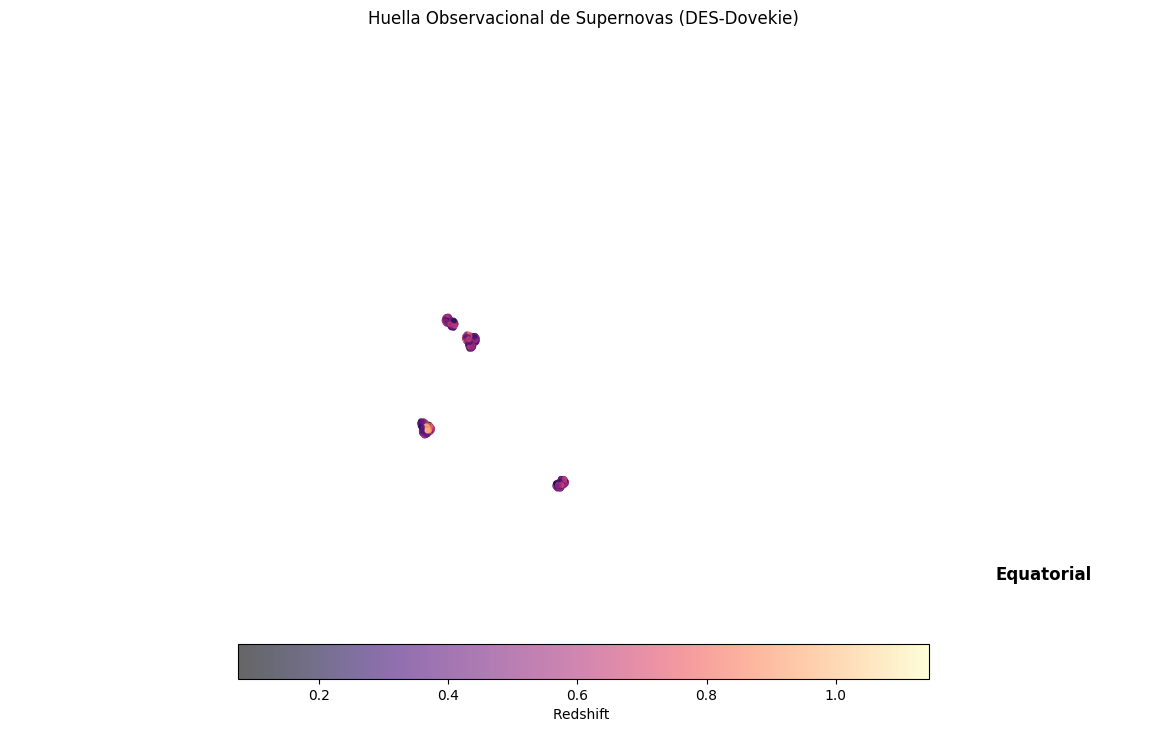

In [4]:
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

!pip install healpy # Install healpy to ensure it's available

# 1. Tu ruta local (Fíjate en la 'r' minúscula al principio)
# Corrected path for Colab environment
ruta_local = r"/content/DES-Dovekie_Metadata.csv"

# 2. Nombres de las columnas exactas del archivo
columnas = "PREFIX CID CIDint IDSURVEY TYPE FIELD CUTFLAG_SNANA ERRFLAG_FIT zHEL zHELERR zCMB zCMBERR zHD zHDERR VPEC VPECERR LENSDMU LENSDMUERR MWEBV HOST_NMATCH HOST_NMATCH2 HOST_OBJID HOST_ZPHOT HOST_ZPHOTERR HOST_ZSPEC HOST_ZSPECERR HOST_RA HOST_DEC HOST_ANGSEP HOST_DDLR HOST_CONFUSION HOST_LOGMASS HOST_LOGMASS_ERR HOST_LOGSFR HOST_LOGSFR_ERR HOST_LOGsSFR HOST_LOGsSFR_ERR HOST_COLOR HOST_COLOR_ERR HOST_MAG_g HOST_MAG_i HOST_SBFLUXCAL_g HOST_SBFLUXCAL_i HOST_SBMAG_g HOST_SBMAG_i PKMJDINI SNRMAX1 SNRMAX2 SNRMAX3 SNRSUM BANDLIST PKMJD PKMJDERR x1 x1ERR c cERR mB mBERR x0 x0ERR COV_x1_c COV_x1_x0 COV_c_x0 NDOF FITCHI2 FITPROB RADIUS_POP PROB_SCONE PROB_SNIRFV19 PROB_SNNDESCC PROB_SNNJ17 PROB_SNNV19 CUTMASK MU MUMODEL MUERR MUERR_RENORM MUERR_RAW MUERR_VPEC MURES MUPULL M0DIF M0DIFERR CHI2_BEAMS PROBCC_BEAMS biasCor_nevt biasCor_mu biasCorErr_mu biasCor_muCOVSCALE biasCor_muCOVADD IDSAMPLE IZBIN".split()

# 3. Leer el archivo local
df = pd.read_csv(ruta_local,
                 sep=r'\s+',           # Separado por espacios (fixed SyntaxWarning)
                 comment='#',         # Ignora comentarios iniciales
                 names=columnas,      # Aplica nuestros nombres de columnas
                 skiprows=1,          # Skip the 'VARNAMES:' row which is read as the first data row
                 low_memory=False)    # Evita warnings de tipos de datos

# 4. LIMPIEZA: Filtramos las supernovas que no tienen coordenadas válidas (-999)
df_limpio = df[(df['HOST_RA'] != -999) & (df['HOST_DEC'] != -999)]

# Extraemos las variables que nos importan
ra = df_limpio['HOST_RA'].astype(float).values
dec = df_limpio['HOST_DEC'].astype(float).values
redshifts = df_limpio['zHD'].astype(float).values

print(f"Total de supernovas leídas y listas para graficar: {len(ra)}")

# 5. CONVERSIÓN A HEALPY (De grados a Radianes esféricos)
phi = np.radians(ra)
theta = np.radians(90.0 - dec)

# 6. GRAFICAR EL CIELO
fig = plt.figure(figsize=(12, 8))

# Generar el fondo del mapa (Mollweide projection)
hp.mollview(title="Huella Observacional de Supernovas (DES-Dovekie)",
            cbar=False,
            coord=['C'],     # Sistema Ecuatorial
            bgcolor='white', # Fondo blanco para documentos/papers
            xsize=2000,      # Alta resolución
            fig=fig.number)

# Proyectar los puntos de las supernovas
scatter = hp.projscatter(theta, phi,
               c=redshifts,     # El color indica el redshift
               cmap='magma',    # Paleta de colores atractiva
               s=10,            # Tamaño del punto
               alpha=0.6)

# Barra de color
plt.colorbar(scatter, label='Redshift ', orientation='horizontal', shrink=0.6, pad=0.05)

plt.show()

Total de supernovas leídas y listas para graficar: 1623


/usr/local/lib/python3.12/dist-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


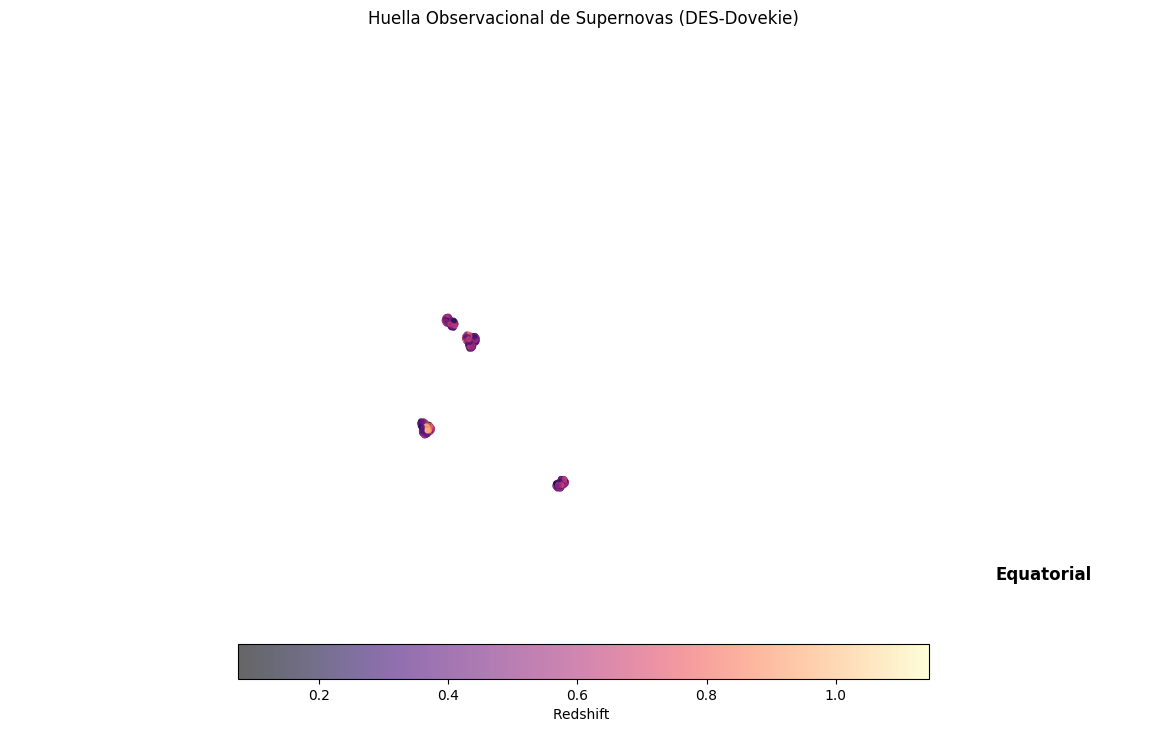

In [5]:
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# 1. Ruta local en Colab
ruta_local = r"/content/DES-Dovekie_Metadata.csv"

# 2. Nombres de las columnas exactas del archivo
columnas = "PREFIX CID CIDint IDSURVEY TYPE FIELD CUTFLAG_SNANA ERRFLAG_FIT zHEL zHELERR zCMB zCMBERR zHD zHDERR VPEC VPECERR LENSDMU LENSDMUERR MWEBV HOST_NMATCH HOST_NMATCH2 HOST_OBJID HOST_ZPHOT HOST_ZPHOTERR HOST_ZSPEC HOST_ZSPECERR HOST_RA HOST_DEC HOST_ANGSEP HOST_DDLR HOST_CONFUSION HOST_LOGMASS HOST_LOGMASS_ERR HOST_LOGSFR HOST_LOGSFR_ERR HOST_LOGsSFR HOST_LOGsSFR_ERR HOST_COLOR HOST_COLOR_ERR HOST_MAG_g HOST_MAG_i HOST_SBFLUXCAL_g HOST_SBFLUXCAL_i HOST_SBMAG_g HOST_SBMAG_i PKMJDINI SNRMAX1 SNRMAX2 SNRMAX3 SNRSUM BANDLIST PKMJD PKMJDERR x1 x1ERR c cERR mB mBERR x0 x0ERR COV_x1_c COV_x1_x0 COV_c_x0 NDOF FITCHI2 FITPROB RADIUS_POP PROB_SCONE PROB_SNIRFV19 PROB_SNNDESCC PROB_SNNJ17 PROB_SNNV19 CUTMASK MU MUMODEL MUERR MUERR_RENORM MUERR_RAW MUERR_VPEC MURES MUPULL M0DIF M0DIFERR CHI2_BEAMS PROBCC_BEAMS biasCor_nevt biasCor_mu biasCorErr_mu biasCor_muCOVSCALE biasCor_muCOVADD IDSAMPLE IZBIN".split()

# 3. Leer el archivo local
df = pd.read_csv(ruta_local,
                 sep=r'\s+',           # Expresión regular corregida
                 comment='#',          # Ignora comentarios iniciales
                 names=columnas,       # Asigna los nombres de las columnas
                 skiprows=1,           # Se salta la línea de VARNAMES
                 low_memory=False)

# BLINDAJE: Forzar que las columnas de coordenadas sean números (si hay error, pone NaN)
df['HOST_RA'] = pd.to_numeric(df['HOST_RA'], errors='coerce')
df['HOST_DEC'] = pd.to_numeric(df['HOST_DEC'], errors='coerce')
df['zHD'] = pd.to_numeric(df['zHD'], errors='coerce')

# 4. LIMPIEZA: Filtramos los -999 y eliminamos cualquier NaN que haya surgido
df_limpio = df[(df['HOST_RA'] != -999.0) & (df['HOST_DEC'] != -999.0)].dropna(subset=['HOST_RA', 'HOST_DEC', 'zHD'])

# Extraemos las variables
ra = df_limpio['HOST_RA'].values
dec = df_limpio['HOST_DEC'].values
redshifts = df_limpio['zHD'].values

print(f"Total de supernovas leídas y listas para graficar: {len(ra)}")

# 5. CONVERSIÓN A HEALPY (Radianes esféricos)
phi = np.radians(ra)
theta = np.radians(90.0 - dec)

# 6. GRAFICAR EL CIELO
fig = plt.figure(figsize=(12, 8))

hp.mollview(title="Huella Observacional de Supernovas (DES-Dovekie)",
            cbar=False,
            coord=['C'],     # Sistema Ecuatorial Celeste
            bgcolor='white',
            xsize=2000,
            fig=fig.number)

# Proyectar los puntos (Tu idea de guardarlo en la variable 'scatter' está perfecta)
scatter = hp.projscatter(theta, phi,
                         c=redshifts,
                         cmap='magma',
                         s=10,
                         alpha=0.6)

# Barra de color
plt.colorbar(scatter, label='Redshift ', orientation='horizontal', shrink=0.6, pad=0.05)

plt.show()

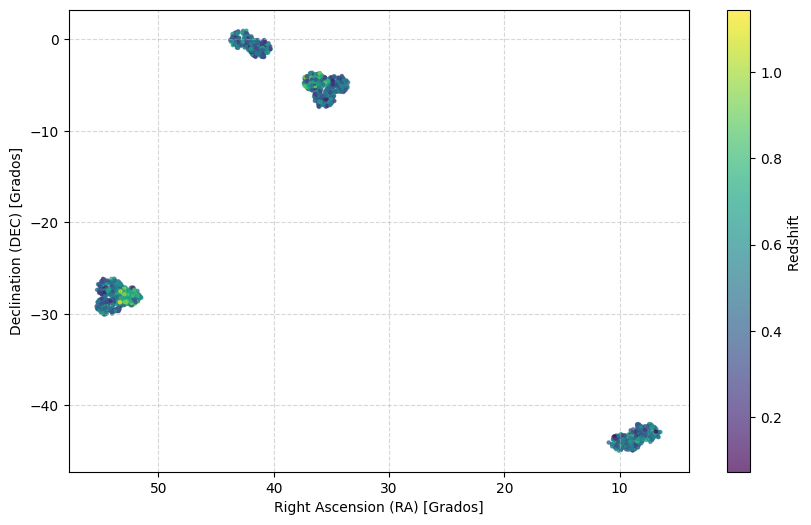

In [6]:
plt.figure(figsize=(10, 6))

# Un scatter plot normal en 2D
plt.scatter(ra, dec, c=redshifts, cmap='viridis', s=5, alpha=0.7)

plt.xlabel('Right Ascension (RA) [Grados]')
plt.ylabel('Declination (DEC) [Grados]')
#plt.title('Zoom a los Campos de Supernovas (DES 5YR)')
plt.colorbar(label='Redshift ')
plt.grid(True, linestyle='--', alpha=0.5)

# Invertir el eje X porque en astronomía el RA se grafica de derecha a izquierda
plt.gca().invert_xaxis()

plt.show()

/usr/local/lib/python3.12/dist-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


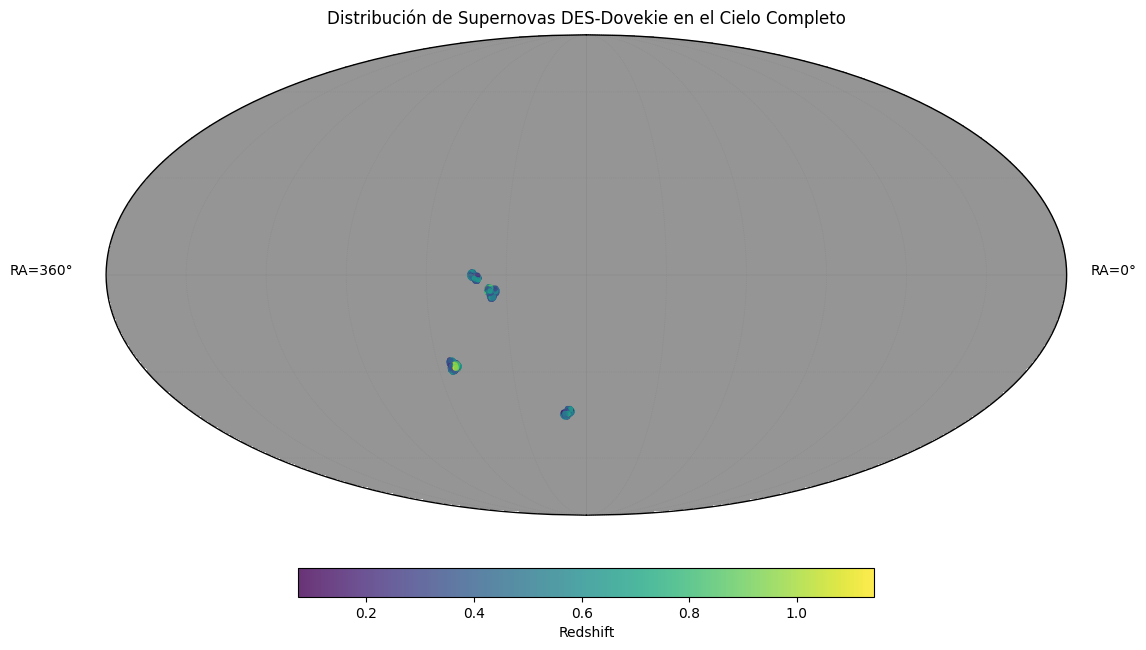

In [7]:
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# 1. Leer los datos (usando tu lógica que ya funciona)
ruta_local = r"/content/DES-Dovekie_Metadata.csv"
columnas = "PREFIX CID CIDint IDSURVEY TYPE FIELD CUTFLAG_SNANA ERRFLAG_FIT zHEL zHELERR zCMB zCMBERR zHD zHDERR VPEC VPECERR LENSDMU LENSDMUERR MWEBV HOST_NMATCH HOST_NMATCH2 HOST_OBJID HOST_ZPHOT HOST_ZPHOTERR HOST_ZSPEC HOST_ZSPECERR HOST_RA HOST_DEC HOST_ANGSEP HOST_DDLR HOST_CONFUSION HOST_LOGMASS HOST_LOGMASS_ERR HOST_LOGSFR HOST_LOGSFR_ERR HOST_LOGsSFR HOST_LOGsSFR_ERR HOST_COLOR HOST_COLOR_ERR HOST_MAG_g HOST_MAG_i HOST_SBFLUXCAL_g HOST_SBFLUXCAL_i HOST_SBMAG_g HOST_SBMAG_i PKMJDINI SNRMAX1 SNRMAX2 SNRMAX3 SNRSUM BANDLIST PKMJD PKMJDERR x1 x1ERR c cERR mB mBERR x0 x0ERR COV_x1_c COV_x1_x0 COV_c_x0 NDOF FITCHI2 FITPROB RADIUS_POP PROB_SCONE PROB_SNIRFV19 PROB_SNNDESCC PROB_SNNJ17 PROB_SNNV19 CUTMASK MU MUMODEL MUERR MUERR_RENORM MUERR_RAW MUERR_VPEC MURES MUPULL M0DIF M0DIFERR CHI2_BEAMS PROBCC_BEAMS biasCor_nevt biasCor_mu biasCorErr_mu biasCor_muCOVSCALE biasCor_muCOVADD IDSAMPLE IZBIN".split()

df = pd.read_csv(ruta_local, sep=r'\s+', comment='#', names=columnas, skiprows=1, low_memory=False)

# Limpieza básica
df['HOST_RA'] = pd.to_numeric(df['HOST_RA'], errors='coerce')
df['HOST_DEC'] = pd.to_numeric(df['HOST_DEC'], errors='coerce')
df_limpio = df[(df['HOST_RA'] != -999.0) & (df['HOST_DEC'] != -999.0)].dropna(subset=['HOST_RA', 'HOST_DEC'])

ra = df_limpio['HOST_RA'].values
dec = df_limpio['HOST_DEC'].values
redshifts = pd.to_numeric(df_limpio['zHD'], errors='coerce').values

# Conversión a radianes
phi = np.radians(ra)
theta = np.radians(90.0 - dec)

# --- TRUCO PARA EL CIELO COMPLETO ---
fig = plt.figure(figsize=(12, 7))

# 1. Dibujamos el mapa base.
# Usamos un color gris muy suave para el fondo del "cielo" para que se vea la forma de la esfera.
hp.mollview(np.zeros(12), # Un mapa vacío para inicializar la vista
            title="Distribución de Supernovas DES-Dovekie en el Cielo Completo",
            cbar=False,
            cmap='Greys', # Fondo gris
            # alpha=0.1,    # Casi transparente - This line caused the TypeError
            fig=fig.number)

# 2. AÑADIMOS LA CUADRÍCULA (Esto es lo que te falta para que parezca "completo")
hp.graticule(dpar=30, dmer=30, color='gray', alpha=0.5, lw=0.5)

# 3. Proyectamos tus supernovas encima
scatter = hp.projscatter(theta, phi,
                         c=redshifts,
                         cmap='viridis', # 'viridis' o 'magma' resaltan mejor
                         s=15,           # Un poco más grandes
                         edgecolors='none',
                         alpha=0.8)

# Añadir etiquetas de los ejes (opcional pero profesional)
plt.text(2.1, 0, "RA=0°", fontsize=10)
plt.text(-2.4, 0, "RA=360°", fontsize=10)

# Barra de color
plt.colorbar(scatter, label='Redshift', orientation='horizontal', shrink=0.5, pad=0.08)

plt.show()

Supernovas de Pantheon+ cargadas: 1701
Supernovas de DES cargadas: 1623


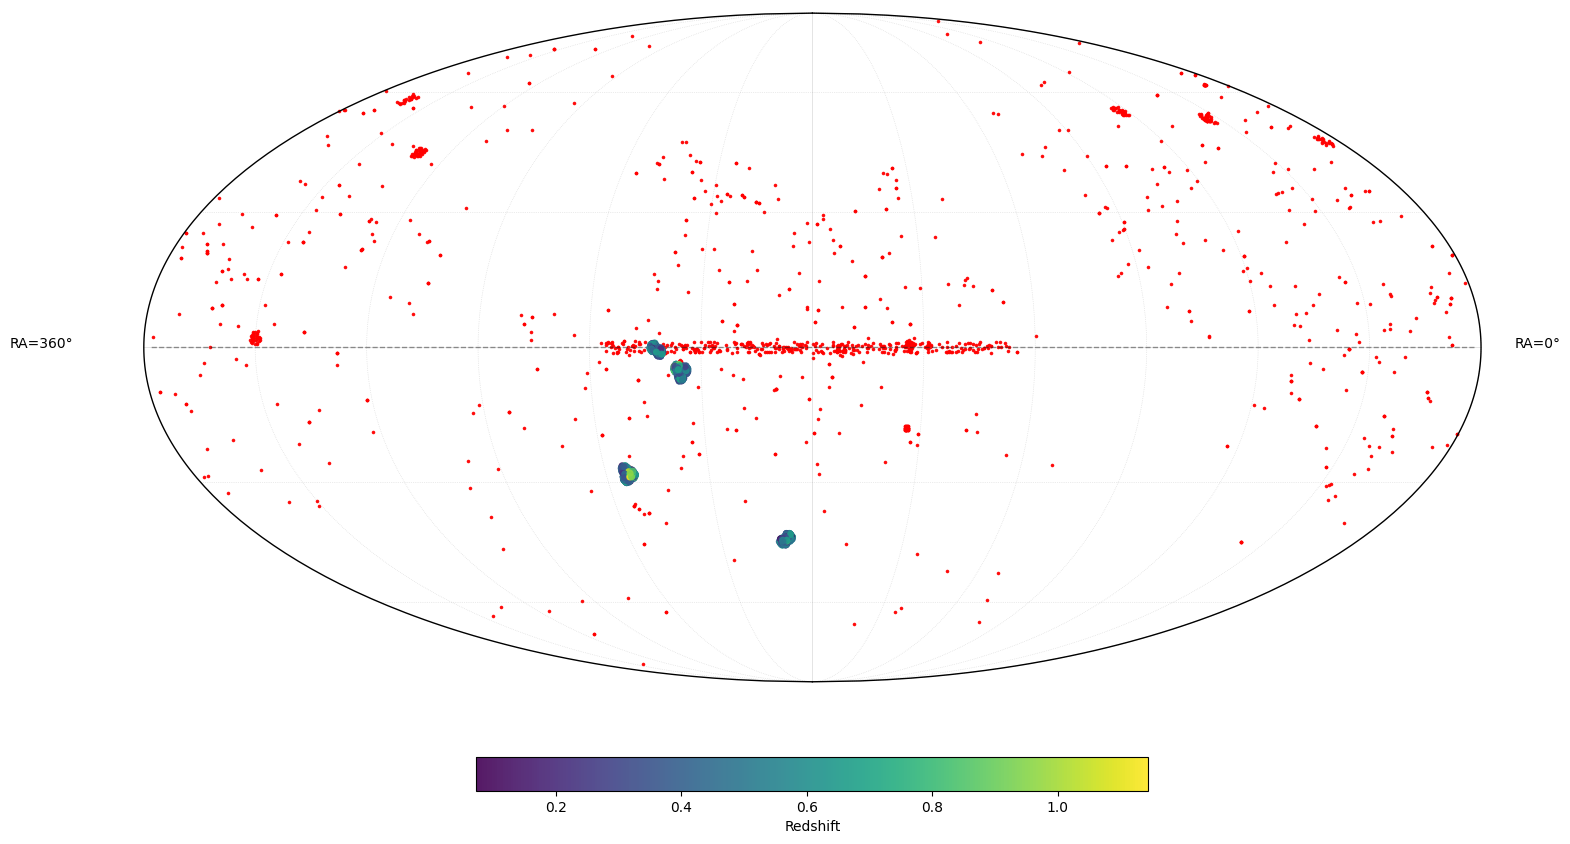

In [11]:
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# ==========================================
# 1. CARGAR DATOS DE FONDO (Pantheon+)
# ==========================================
# Cambiamos la ruta a tu archivo .dat guardado localmente
ruta_pantheon = r"/content/Pantheon+SH0ES.dat.txt"

# Leemos el archivo. Pantheon+ suele estar bien tabulado y no necesita skiprows.
df_pantheon = pd.read_csv(ruta_pantheon, sep=r'\s+', low_memory=False)

# Extraemos coordenadas y las convertimos a radianes (Healpy usa Colatitud, por eso 90 - DEC)
ra_pan = df_pantheon['RA'].values
dec_pan = df_pantheon['DEC'].values
phi_pan = np.radians(ra_pan)
theta_pan = np.radians(90.0 - dec_pan)

print(f"Supernovas de Pantheon+ cargadas: {len(ra_pan)}")

# ==========================================
# 2. CARGAR TUS DATOS (DES-Dovekie)
# ==========================================
ruta_des = r"/content/DES-Dovekie_Metadata.csv"
columnas_des = "PREFIX CID CIDint IDSURVEY TYPE FIELD CUTFLAG_SNANA ERRFLAG_FIT zHEL zHELERR zCMB zCMBERR zHD zHDERR VPEC VPECERR LENSDMU LENSDMUERR MWEBV HOST_NMATCH HOST_NMATCH2 HOST_OBJID HOST_ZPHOT HOST_ZPHOTERR HOST_ZSPEC HOST_ZSPECERR HOST_RA HOST_DEC HOST_ANGSEP HOST_DDLR HOST_CONFUSION HOST_LOGMASS HOST_LOGMASS_ERR HOST_LOGSFR HOST_LOGSFR_ERR HOST_LOGsSFR HOST_LOGsSFR_ERR HOST_COLOR HOST_COLOR_ERR HOST_MAG_g HOST_MAG_i HOST_SBFLUXCAL_g HOST_SBFLUXCAL_i HOST_SBMAG_g HOST_SBMAG_i PKMJDINI SNRMAX1 SNRMAX2 SNRMAX3 SNRSUM BANDLIST PKMJD PKMJDERR x1 x1ERR c cERR mB mBERR x0 x0ERR COV_x1_c COV_x1_x0 COV_c_x0 NDOF FITCHI2 FITPROB RADIUS_POP PROB_SCONE PROB_SNIRFV19 PROB_SNNDESCC PROB_SNNJ17 PROB_SNNV19 CUTMASK MU MUMODEL MUERR MUERR_RENORM MUERR_RAW MUERR_VPEC MURES MUPULL M0DIF M0DIFERR CHI2_BEAMS PROBCC_BEAMS biasCor_nevt biasCor_mu biasCorErr_mu biasCor_muCOVSCALE biasCor_muCOVADD IDSAMPLE IZBIN".split()

df_des = pd.read_csv(ruta_des, sep=r'\s+', comment='#', names=columnas_des, skiprows=1, low_memory=False)

# Limpieza y conversión de Redshift
df_des['HOST_RA'] = pd.to_numeric(df_des['HOST_RA'], errors='coerce')
df_des['HOST_DEC'] = pd.to_numeric(df_des['HOST_DEC'], errors='coerce')
df_des['zHD'] = pd.to_numeric(df_des['zHD'], errors='coerce')

df_des_limpio = df_des[(df_des['HOST_RA'] != -999.0) & (df_des['HOST_DEC'] != -999.0)].dropna(subset=['HOST_RA', 'HOST_DEC', 'zHD'])

ra_des = df_des_limpio['HOST_RA'].values
dec_des = df_des_limpio['HOST_DEC'].values
redshifts_des = df_des_limpio['zHD'].values # Esta variable dará los colores

phi_des = np.radians(ra_des)
theta_des = np.radians(90.0 - dec_des)
print(f"Supernovas de DES cargadas: {len(ra_des)}")
# ==========================================
# 3. GRAFICAR EL CIELO COMPLETO
# ==========================================
fig = plt.figure(figsize=(14, 10))

# Mapa base
#hp.mollview(title="Mapa de Supernovas: Fondo Pantheon+ y Muestra DES-Dovekie",
            #cbar=False, coord=['C'], bgcolor='white', fig=fig.number)

hp.graticule(dpar=30, dmer=30, color='gray', alpha=0.3, lw=0.5)

# 3.1 Supernovas de fondo (Pantheon+) con mejor visibilidad
hp.projscatter(theta_pan, phi_pan,
               s=10,                  # Aumentamos el tamaño para que se vean
               color='red',        # Un gris un poco más oscuro y brillante
               alpha=0.9,             # Menos transparentes
               marker='.',
               label='Pantheon+ (Fondo)')

# 3.2 TUS Supernovas (DES-Dovekie) con escala de colores "Verdes y Azules" (viridis)
scatter = hp.projscatter(theta_des, phi_des,
                         c=redshifts_des,      # Color basado en redshift
                         cmap='viridis',       # El mapa de colores que pediste
                         s=25, marker='o',
                         edgecolors='none', alpha=0.9, zorder=10)

# 3.3 Línea del Ecuador Galáctico
hp.projplot(np.pi/2 * np.ones(100), np.linspace(0, 2*np.pi, 100), 'k--', alpha=0.4, lw=1)

# 3.4 TEXTOS Y BARRA DE COLOR (Lo que pediste agregar)
plt.text(2.1, 0, "RA=0°", fontsize=10)
plt.text(-2.4, 0, "RA=360°", fontsize=10)

# Agregamos la barra de color usando el objeto 'scatter'
cb = plt.colorbar(scatter, label='Redshift', orientation='horizontal', shrink=0.5, pad=0.08)
cb.ax.tick_params(labelsize=10)

plt.show()

Supernovas de Pantheon+ (Fondo): 1701
Supernovas de DES-Dovekie (Destacadas): 1623


/usr/local/lib/python3.12/dist-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


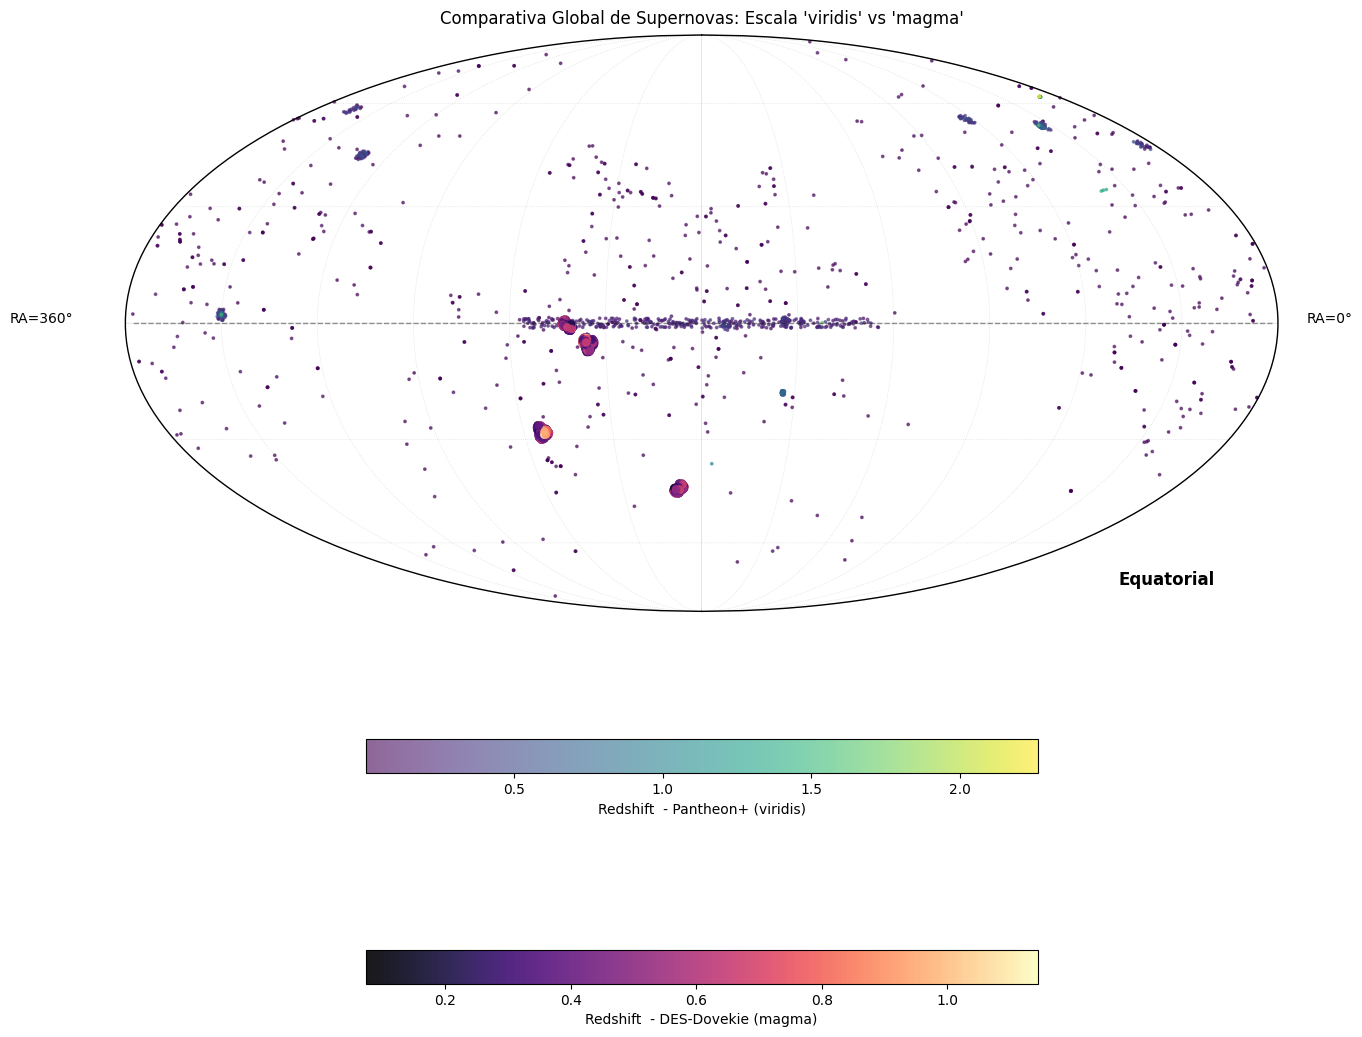

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import matplotlib.cm as cm # Para manejar los colormaps

# ==============================================================================
# 1. CARGAR Y PREPARAR LOS DATOS (Asumiendo local o Colab)
# ==============================================================================

# 1.1 FONDO: Pantheon+ (Oficial)
ruta_pantheon = r"/content/Pantheon+SH0ES.dat.txt" # O tu ruta local
df_pantheon = pd.read_csv(ruta_pantheon, sep=r'\s+', low_memory=False)

# Extraemos coordenadas y Redshift (limpiando posibles nulos)
df_pan_limpio = df_pantheon.dropna(subset=['RA', 'DEC', 'zHD'])
ra_pan = df_pan_limpio['RA'].values
dec_pan = df_pan_limpio['DEC'].values
z_pan = df_pan_limpio['zHD'].values

print(f"Supernovas de Pantheon+ (Fondo): {len(ra_pan)}")

# 1.2 MUESTRA A DESTACAR: DES-Dovekie
ruta_des = r"/content/DES-Dovekie_Metadata.csv" # O tu ruta local
columnas_des = "PREFIX CID CIDint IDSURVEY TYPE FIELD CUTFLAG_SNANA ERRFLAG_FIT zHEL zHELERR zCMB zCMBERR zHD zHDERR VPEC VPECERR LENSDMU LENSDMUERR MWEBV HOST_NMATCH HOST_NMATCH2 HOST_OBJID HOST_ZPHOT HOST_ZPHOTERR HOST_ZSPEC HOST_ZSPECERR HOST_RA HOST_DEC HOST_ANGSEP HOST_DDLR HOST_CONFUSION HOST_LOGMASS HOST_LOGMASS_ERR HOST_LOGSFR HOST_LOGSFR_ERR HOST_LOGsSFR HOST_LOGsSFR_ERR HOST_COLOR HOST_COLOR_ERR HOST_MAG_g HOST_MAG_i HOST_SBFLUXCAL_g HOST_SBFLUXCAL_i HOST_SBMAG_g HOST_SBMAG_i PKMJDINI SNRMAX1 SNRMAX2 SNRMAX3 SNRSUM BANDLIST PKMJD PKMJDERR x1 x1ERR c cERR mB mBERR x0 x0ERR COV_x1_c COV_x1_x0 COV_c_x0 NDOF FITCHI2 FITPROB RADIUS_POP PROB_SCONE PROB_SNIRFV19 PROB_SNNDESCC PROB_SNNJ17 PROB_SNNV19 CUTMASK MU MUMODEL MUERR MUERR_RENORM MUERR_RAW MUERR_VPEC MURES MUPULL M0DIF M0DIFERR CHI2_BEAMS PROBCC_BEAMS biasCor_nevt biasCor_mu biasCorErr_mu biasCor_muCOVSCALE biasCor_muCOVADD IDSAMPLE IZBIN".split()

df_des = pd.read_csv(ruta_des, sep=r'\s+', comment='#', names=columnas_des, skiprows=1, low_memory=False)

# Limpieza profunda de DES (coordenadas -999 y Redshift nulos)
df_des['HOST_RA'] = pd.to_numeric(df_des['HOST_RA'], errors='coerce')
df_des['HOST_DEC'] = pd.to_numeric(df_des['HOST_DEC'], errors='coerce')
df_des['zHD'] = pd.to_numeric(df_des['zHD'], errors='coerce')
df_des_limpio = df_des[(df_des['HOST_RA'] != -999.0) & (df_des['HOST_DEC'] != -999.0)].dropna(subset=['HOST_RA', 'HOST_DEC', 'zHD'])

ra_des = df_des_limpio['HOST_RA'].values
dec_des = df_des_limpio['HOST_DEC'].values
z_des = df_des_limpio['zHD'].values

print(f"Supernovas de DES-Dovekie (Destacadas): {len(ra_des)}")

# ==============================================================================
# 2. CONVERSIÓN DE COORDENADAS A RADIANES (Healpy usa Colatitud)
# ==============================================================================
# Pantheon
phi_pan = np.radians(ra_pan)
theta_pan = np.radians(90.0 - dec_pan)

# DES
phi_des = np.radians(ra_des)
theta_des = np.radians(90.0 - dec_des)

# ==============================================================================
# 3. GRAFICAR EL CIELO COMPLETO CON DOBLE ESCALA DE COLORES
# ==============================================================================
# Aumentamos el tamaño vertical de la figura para acomodar dos barras de color
fig = plt.figure(figsize=(14, 12))

# Mapa base vacío y blanco
hp.mollview(title="Comparativa Global de Supernovas: Escala 'viridis' vs 'magma'",
            cbar=False, coord=['C'], bgcolor='white', fig=fig.number)

# Graticula de referencia
hp.graticule(dpar=30, dmer=30, color='gray', alpha=0.3, lw=0.5)

# 3.1 DIBUJAR FONDO: Pantheon+ con 'viridis'
# Usamos puntos medianos y transparencia moderada
scatter_pan = hp.projscatter(theta_pan, phi_pan,
                              c=z_pan,            # Color basado en redshift
                              cmap='viridis',     # Escala verde/azul
                              s=12, marker='.',
                              alpha=0.6,          # Transparencia para efecto "nube"
                              label='Pantheon+ (z con viridis)')

# 3.2 DIBUJAR DES: DES-Dovekie DESTACADAS con 'magma'
# Usamos puntos más grandes, opacos y zorder alto para que queden ENCIMA
scatter_des = hp.projscatter(theta_des, phi_des,
                              c=z_des,            # Color basado en redshift
                              cmap='magma',       # Escala rosa/naranja (destacada)
                              s=35, marker='o',
                              edgecolors='none',  # Sin bordes para pureza de color
                              alpha=0.9,          # Casi opaco
                              zorder=10)          # ¡¡Crucial!! Para graficar encima del fondo

# 3.3 Contexto adicional (RA y Ecuador Galáctico)
plt.text(2.1, 0, "RA=0°", fontsize=10)
plt.text(-2.4, 0, "RA=360°", fontsize=10)
hp.projplot(np.pi/2 * np.ones(100), np.linspace(0, 2*np.pi, 100), 'k--', alpha=0.4, lw=1)

# ==============================================================================
# 4. DOBLE BARRA DE COLOR HORIZONTAL APILADA
# ==========================================
# Usamos 'pad' y 'shrink' cuidadosamente para que no se encimen y se vea simétrico

# Barra 1: DES-Dovekie (Destacada, va arriba)
# pad=0.08 separa la barra del mapa
cb_des = plt.colorbar(scatter_des,
                       label='Redshift  - DES-Dovekie (magma)',
                       orientation='horizontal', shrink=0.5, pad=0.08)
cb_des.ax.tick_params(labelsize=10)

# Barra 2: Pantheon+ (Fondo, va abajo)
# pad=0.15 acomoda el espacio de la primera barra y su label
cb_pan = plt.colorbar(scatter_pan,
                       label='Redshift  - Pantheon+ (viridis)',
                       orientation='horizontal', shrink=0.5, pad=0.15)
cb_pan.ax.tick_params(labelsize=10)

plt.show()

Supernovas de Pantheon+ : 1701

Supernovas de DES: 1623

In [13]:
# ==============================================================================
# INSTALAR HEALPY
# ==============================================================================
!pip install healpy -q

Columnas del catálogo principal:
Index(['SNID', 'IAUC', 'host', 'RA', 'Dec', 'RA_host', 'Dec_host', 'zhel',
       'zcmb', 'zhelerr', 'zHD', 'zHDerr', 'PV', 'vpecerr', 'RA_group',
       'Dec_group', 'zhel_group', 'zcmb_group', 'zHD_group', 'PV_group',
       'in_group', 'has_host', 'is_SNz'],
      dtype='object')

Primeras filas de REDSHIFT_CMB:
      CID  REDSHIFT_CMB
0   1981B      0.003502
1  2019np      0.005502
2  2013aa      0.004781
3  000006      0.230439
4  000010      0.245937

Número de supernovas con match: 2285


<Figure size 1400x800 with 0 Axes>

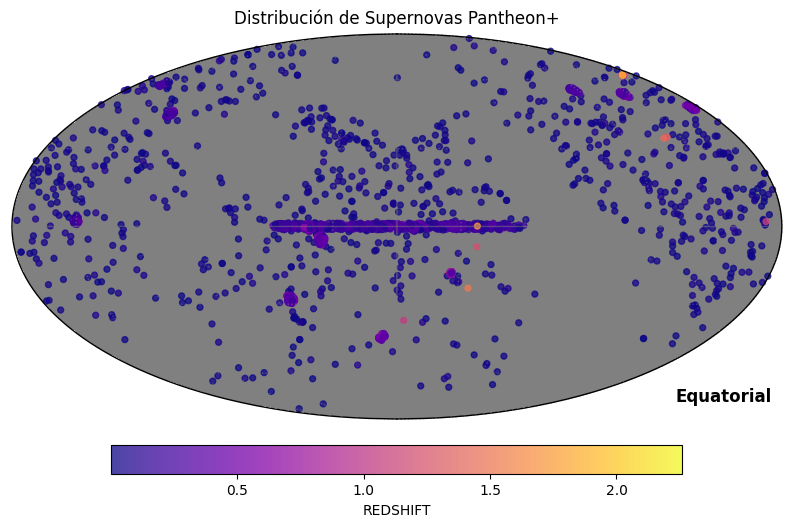

In [16]:


# ==============================================================================
# IMPORTS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

# ==============================================================================
# 1. CARGAR all_redshifts_PVs.csv
# ==============================================================================
df_main = pd.read_csv("all_redshifts_PVs (1).csv")

print("Columnas del catálogo principal:")
print(df_main.columns)

# ==============================================================================
# 2. CARGAR REDSHIFT_CMB.txt
# ==============================================================================
rows = []

with open("REDSHIFT_CMB.txt", "r") as f:

    lines = f.readlines()

    for line in lines:

        # Ignorar encabezado
        if line.startswith("VARNAMES"):
            continue

        # Solo líneas válidas
        if line.startswith("SN:"):

            parts = line.split()

            cid = parts[1]
            zcmb = float(parts[2])

            rows.append([cid, zcmb])

# Convertir a DataFrame
df_zcmb = pd.DataFrame(rows, columns=["CID", "REDSHIFT_CMB"])

print("\nPrimeras filas de REDSHIFT_CMB:")
print(df_zcmb.head())

# ==============================================================================
# 3. HACER MATCH ENTRE LOS DATASETS
# ==============================================================================
# SNID del CSV corresponde al CID del TXT

df = pd.merge(
    df_main,
    df_zcmb,
    left_on="SNID",
    right_on="CID",
    how="inner"
)

print(f"\nNúmero de supernovas con match: {len(df)}")

# ==============================================================================
# 4. EXTRAER VARIABLES
# ==============================================================================
ra = df["RA"].values
dec = df["Dec"].values
zcmb = df["REDSHIFT_CMB"].values

# ==============================================================================
# 5. CONVERSIÓN A COORDENADAS HEALPY
# ==============================================================================
# phi = longitud
phi = np.radians(ra)

# theta = colatitud
theta = np.radians(90.0 - dec)

# ==============================================================================
# 6. CREAR MAPA BASE
# ==============================================================================
plt.figure(figsize=(14,8))

nside = 32
npix = hp.nside2npix(nside)

mapa_vacio = np.zeros(npix)

hp.mollview(
    mapa_vacio,
    coord=['C'],
    title='Distribución de Supernovas Pantheon+',
    cbar=False,
    cmap='binary_r'
)

# ==============================================================================
# 7. AGREGAR GRILLA
# ==============================================================================
hp.graticule(
    dpar=30,
    dmer=30,
    color='gray',
    alpha=0.5
)

# ==============================================================================
# 8. GRAFICAR SUPERNOVAS
# ==============================================================================
scatter = hp.projscatter(
    theta,
    phi,
    lonlat=False,
    c=zcmb,
    cmap='plasma',
    s=18,
    alpha=0.75
)

# ==============================================================================
# 9. COLORBAR
# ==============================================================================
cbar = plt.colorbar(
    scatter,
    orientation='horizontal',
    shrink=0.7,
    pad=0.05
)

cbar.set_label("REDSHIFT")

plt.show()

Total de supernovas a graficar: 2287


<Figure size 1400x800 with 0 Axes>

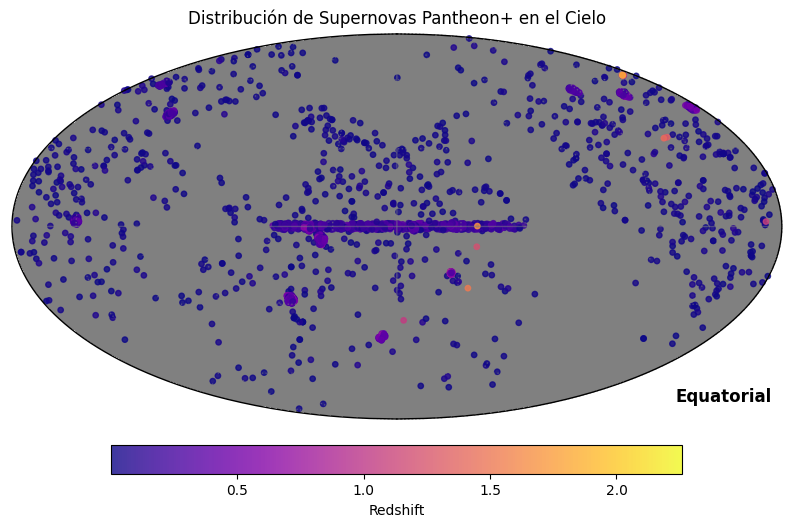

In [17]:
# ==============================================================================
# IMPORTS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

# ==============================================================================
# 1. CARGAR DATOS (¡Solo el CSV!)
# ==============================================================================
# Asegúrate de tener la ruta correcta a tu archivo
df = pd.read_csv("all_redshifts_PVs (1).csv")

# Extraemos directamente las columnas que ya vienen listas
ra = df["RA"].values
dec = df["Dec"].values
zcmb = df["zcmb"].values  # Ya viene en el catálogo principal

print(f"Total de supernovas a graficar: {len(df)}")

# ==============================================================================
# 2. CREAR MAPA BASE
# ==============================================================================
plt.figure(figsize=(14,8))

nside = 32
npix = hp.nside2npix(nside)
mapa_vacio = np.zeros(npix)

hp.mollview(
    mapa_vacio,
    coord=['C'], # 'C' = Equatorial (RA/Dec)
    title='Distribución de Supernovas Pantheon+ en el Cielo',
    cbar=False,
    cmap='binary_r' # Fondo blanco
)

# ==============================================================================
# 3. AGREGAR GRILLA
# ==============================================================================
hp.graticule(
    dpar=30,
    dmer=30,
    color='gray',
    alpha=0.5
)

# ==============================================================================
# 4. GRAFICAR SUPERNOVAS (Con el truco lonlat=True)
# ==============================================================================
scatter = hp.projscatter(
    ra,          # Simplemente pasamos RA en grados
    dec,         # Simplemente pasamos Dec en grados
    lonlat=True, # ¡Esta magia evita calcular phi y theta a mano!
    c=zcmb,
    cmap='plasma',
    s=15,        # Tamaño de los puntos
    alpha=0.8
)

# ==============================================================================
# 5. COLORBAR
# ==============================================================================
cbar = plt.colorbar(
    scatter,
    orientation='horizontal',
    shrink=0.7,
    pad=0.05
)

cbar.set_label("Redshift")

plt.show()